# Backtesting (Rolling Forecast Origin) for Demand Forecasting

This notebook implements rolling-origin backtesting for ARIMA, XGBoost, and LSTM models.

**Steps:**
- Define backtesting parameters (horizon, window, step)
- Sequentially split data and retrain models
- Forecast and evaluate for each fold
- Aggregate and visualize results

---

## 1. Setup and Configuration
Set up libraries, parameters, and utility functions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Backtesting parameters (common for all models)
TRAIN_WINDOW = 30  # days
FORECAST_HORIZON = 7  # days ahead
STEP_SIZE = 7  # days
LOOKBACK = 3  # days

# Utility: MAPE and Bias
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
def bias(y_true, y_pred):
    return np.mean(y_pred - y_true)

## 2. Data Preparation
Load and preprocess the feature-engineered dataset.

In [2]:
# Load data
data = pd.read_csv('../data/processed/feature_engineered.csv', parse_dates=['date'])
data = data.sort_values('date')

# For ARIMA: focus on one region
region = data['region'].mode()[0]
region_data = data[data['region'] == region].copy()
region_data = region_data.groupby('date', as_index=False).mean(numeric_only=True)
region_data.set_index('date', inplace=True)
ts = region_data['usage_cpu'].asfreq('D').fillna(method='ffill')

# For XGBoost/LSTM: drop leakage features
ignore_cols = ['date', 'region', 'resource_type', 'usage_cpu', 'usage_storage']
leakage_cols = [col for col in data.columns if ('usage_cpu' in col or 'cpu' in col) and col not in ['usage_cpu']]
feature_cols = [col for col in data.columns if col not in ignore_cols + leakage_cols]

# Drop rows with NaNs in feature columns before scaling and backtesting
data = data.dropna(subset=feature_cols).reset_index(drop=True)

## 3. Backtesting Loop
Perform rolling-origin evaluation for each model.

### 3.1 ARIMA Rolling-Origin Backtest
For each fold, fit ARIMA on the expanding window and forecast the next horizon. Collect metrics for each fold.

In [3]:
# ARIMA rolling-origin backtest (with debug prints)
arima_metrics = []
arima_forecasts = []
dates = ts.index
n_total = len(ts)
start = 0
fold = 0
print(f"ARIMA: n_total={n_total}, TRAIN_WINDOW={TRAIN_WINDOW}, FORECAST_HORIZON={FORECAST_HORIZON}, STEP_SIZE={STEP_SIZE}")
while start + TRAIN_WINDOW + FORECAST_HORIZON <= n_total:
    train_end = start + TRAIN_WINDOW
    test_end = train_end + FORECAST_HORIZON
    ts_train = ts.iloc[start:train_end]
    ts_test = ts.iloc[train_end:test_end]
    if len(ts_test) == 0 or ts_test.isnull().any():
        print(f"ARIMA fold {fold}: Skipped (empty or NaN in test set, start={start}, train_end={train_end}, test_end={test_end})")
        start += STEP_SIZE
        fold += 1
        continue
    print(f"ARIMA fold {fold}: train [{ts_train.index[0]} - {ts_train.index[-1]}], test [{ts_test.index[0]} - {ts_test.index[-1]}]")
    model = ARIMA(ts_train, order=(1,1,1))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=FORECAST_HORIZON)
    mae = mean_absolute_error(ts_test, forecast)
    rmse = np.sqrt(mean_squared_error(ts_test, forecast))
    mape_val = mape(ts_test, forecast)
    bias_val = bias(ts_test, forecast)
    arima_metrics.append({'start': ts_test.index[0], 'end': ts_test.index[-1], 'MAE': mae, 'RMSE': rmse, 'MAPE': mape_val, 'Bias': bias_val})
    arima_forecasts.append(pd.DataFrame({'date': ts_test.index, 'actual': ts_test.values, 'forecast': forecast.values}))
    start += STEP_SIZE
    fold += 1
arima_metrics_df = pd.DataFrame(arima_metrics)
if arima_forecasts:
    arima_forecast_df = pd.concat(arima_forecasts, ignore_index=True)
else:
    arima_forecast_df = pd.DataFrame(columns=['date','actual','forecast'])
print(f"ARIMA: {len(arima_metrics)} folds generated.")
arima_metrics_df.head()

ARIMA: n_total=90, TRAIN_WINDOW=30, FORECAST_HORIZON=7, STEP_SIZE=7
ARIMA fold 0: train [2023-01-01 00:00:00 - 2023-01-30 00:00:00], test [2023-01-31 00:00:00 - 2023-02-06 00:00:00]
ARIMA fold 1: train [2023-01-08 00:00:00 - 2023-02-06 00:00:00], test [2023-02-07 00:00:00 - 2023-02-13 00:00:00]
ARIMA fold 2: train [2023-01-15 00:00:00 - 2023-02-13 00:00:00], test [2023-02-14 00:00:00 - 2023-02-20 00:00:00]
ARIMA fold 3: train [2023-01-22 00:00:00 - 2023-02-20 00:00:00], test [2023-02-21 00:00:00 - 2023-02-27 00:00:00]
ARIMA fold 4: train [2023-01-29 00:00:00 - 2023-02-27 00:00:00], test [2023-02-28 00:00:00 - 2023-03-06 00:00:00]
ARIMA fold 5: train [2023-02-05 00:00:00 - 2023-03-06 00:00:00], test [2023-03-07 00:00:00 - 2023-03-13 00:00:00]
ARIMA fold 3: train [2023-01-22 00:00:00 - 2023-02-20 00:00:00], test [2023-02-21 00:00:00 - 2023-02-27 00:00:00]
ARIMA fold 4: train [2023-01-29 00:00:00 - 2023-02-27 00:00:00], test [2023-02-28 00:00:00 - 2023-03-06 00:00:00]
ARIMA fold 5: train 

,start,end,MAE,RMSE,MAPE,Bias
0,2023-01-31,2023-02-06,6.089570,6.901044,7.811593,-0.832352
1,2023-02-07,2023-02-13,5.919037,6.398581,7.646490,-0.647965
2,2023-02-14,2023-02-20,4.841578,6.286423,6.378853,0.436750
3,2023-02-21,2023-02-27,9.040586,10.669622,11.579226,-1.509155
4,2023-02-28,2023-03-06,6.473261,8.074895,8.742255,-6.473261


### 3.2 XGBoost Rolling-Origin Backtest
For each fold, fit XGBoost on the expanding window and forecast the next horizon. Collect metrics for each fold.

In [4]:
# XGBoost rolling-origin backtest (with debug prints)
xgb_metrics = []
xgb_forecasts = []
data = data.sort_values('date')
dates = data['date'].unique()
n_total = len(dates)
start = 0
fold = 0
print(f"XGBoost: n_total={n_total}, TRAIN_WINDOW={TRAIN_WINDOW}, FORECAST_HORIZON={FORECAST_HORIZON}, STEP_SIZE={STEP_SIZE}")
while start + TRAIN_WINDOW + FORECAST_HORIZON <= n_total:
    train_end = start + TRAIN_WINDOW
    test_end = train_end + FORECAST_HORIZON
    train_idx = (data['date'] >= dates[start]) & (data['date'] < dates[train_end])
    test_idx = (data['date'] >= dates[train_end]) & (data['date'] < dates[test_end])
    X_train = data.loc[train_idx, feature_cols]
    y_train = data.loc[train_idx, 'usage_cpu']
    X_test = data.loc[test_idx, feature_cols]
    y_test = data.loc[test_idx, 'usage_cpu']
    # Only proceed if test set is not empty and has no NaNs
    if len(y_test) == 0 or np.isnan(y_test).any():
        print(f"XGBoost fold {fold}: Skipped (empty or NaN in test set, start={start}, train_end={train_end}, test_end={test_end})")
        start += STEP_SIZE
        fold += 1
        continue
    print(f"XGBoost fold {fold}: train [{dates[start]} - {dates[train_end-1]}], test [{dates[train_end]} - {dates[test_end-1]}]")
    # Fit XGBoost
    model = XGBRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    forecast = model.predict(X_test)
    # Metrics
    # Use valid datetime for start/end from dates array
    fold_start_date = pd.to_datetime(dates[train_end]) if train_end < len(dates) else pd.NaT
    fold_end_date = pd.to_datetime(dates[test_end-1]) if test_end-1 < len(dates) else pd.NaT
    mae = mean_absolute_error(y_test, forecast)
    rmse = np.sqrt(mean_squared_error(y_test, forecast))
    mape_val = mape(y_test, forecast)
    bias_val = bias(y_test, forecast)
    xgb_metrics.append({'start': fold_start_date, 'end': fold_end_date, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape_val, 'Bias': bias_val})
    xgb_forecasts.append(pd.DataFrame({'date': data.loc[test_idx, 'date'], 'actual': y_test.values, 'forecast': forecast}))
    start += STEP_SIZE
    fold += 1
xgb_metrics_df = pd.DataFrame(xgb_metrics)
if xgb_forecasts:
    xgb_forecast_df = pd.concat(xgb_forecasts, ignore_index=True)
else:
    xgb_forecast_df = pd.DataFrame(columns=['date','actual','forecast'])
print(f"XGBoost: {len(xgb_metrics)} folds generated.")
xgb_metrics_df.head()

XGBoost: n_total=83, TRAIN_WINDOW=30, FORECAST_HORIZON=7, STEP_SIZE=7
XGBoost fold 0: train [2023-01-08 00:00:00 - 2023-02-06 00:00:00], test [2023-02-07 00:00:00 - 2023-02-13 00:00:00]
XGBoost fold 1: train [2023-01-15 00:00:00 - 2023-02-13 00:00:00], test [2023-02-14 00:00:00 - 2023-02-20 00:00:00]
XGBoost fold 1: train [2023-01-15 00:00:00 - 2023-02-13 00:00:00], test [2023-02-14 00:00:00 - 2023-02-20 00:00:00]
XGBoost fold 2: train [2023-01-22 00:00:00 - 2023-02-20 00:00:00], test [2023-02-21 00:00:00 - 2023-02-27 00:00:00]
XGBoost fold 3: train [2023-01-29 00:00:00 - 2023-02-27 00:00:00], test [2023-02-28 00:00:00 - 2023-03-06 00:00:00]
XGBoost fold 2: train [2023-01-22 00:00:00 - 2023-02-20 00:00:00], test [2023-02-21 00:00:00 - 2023-02-27 00:00:00]
XGBoost fold 3: train [2023-01-29 00:00:00 - 2023-02-27 00:00:00], test [2023-02-28 00:00:00 - 2023-03-06 00:00:00]
XGBoost fold 4: train [2023-02-05 00:00:00 - 2023-03-06 00:00:00], test [2023-03-07 00:00:00 - 2023-03-13 00:00:00]
XG

,start,end,MAE,RMSE,MAPE,Bias
0,2023-02-07,2023-02-13,13.018940,15.812094,17.741161,-1.243809
1,2023-02-14,2023-02-20,12.402516,14.689029,17.232268,0.178358
2,2023-02-21,2023-02-27,13.994461,16.759000,20.415626,2.950359
3,2023-02-28,2023-03-06,12.467411,14.789373,18.119799,1.183741
4,2023-03-07,2023-03-13,13.542566,15.939159,18.754946,-1.148086


### 3.3 LSTM Rolling-Origin Backtest
For each fold, fit LSTM on the expanding window and forecast the next horizon. Collect metrics for each fold. (Assumes LSTM preprocessing and model code is available.)

In [6]:
# LSTM rolling-origin backtest (with debug prints and NaN checks)
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense
lstm_metrics = []
lstm_forecasts = []
scaler = MinMaxScaler()
data_scaled = data.copy()
data_scaled[feature_cols] = scaler.fit_transform(data[feature_cols])
dates = data_scaled['date'].unique()
n_total = len(dates)
start = 0
fold = 0
# Parameters are now set globally in Setup and Configuration section
def create_lstm_dataset(X, y, lookback=LOOKBACK):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)
print(f"LSTM: n_total={n_total}, TRAIN_WINDOW={TRAIN_WINDOW}, FORECAST_HORIZON={FORECAST_HORIZON}, STEP_SIZE={STEP_SIZE}, LOOKBACK={LOOKBACK}")
while start + TRAIN_WINDOW + FORECAST_HORIZON + LOOKBACK <= n_total:
    train_end = start + TRAIN_WINDOW
    test_end = train_end + FORECAST_HORIZON
    train_idx = (data_scaled['date'] >= dates[start]) & (data_scaled['date'] < dates[train_end])
    test_idx = (data_scaled['date'] >= dates[train_end]) & (data_scaled['date'] < dates[test_end])
    X_train = data_scaled.loc[train_idx, feature_cols].values
    y_train = data_scaled.loc[train_idx, 'usage_cpu'].values
    X_test = data_scaled.loc[test_idx, feature_cols].values
    y_test = data_scaled.loc[test_idx, 'usage_cpu'].values
    # Only proceed if test set is not empty and has no NaNs
    if len(y_test) == 0 or np.isnan(y_test).any():
        print(f"LSTM fold {fold}: Skipped (empty or NaN in test set, start={start}, train_end={train_end}, test_end={test_end})")
        start += STEP_SIZE
        fold += 1
        continue
    # Create LSTM datasets
    X_train_lstm, y_train_lstm = create_lstm_dataset(X_train, y_train, lookback=LOOKBACK)
    X_test_lstm, y_test_lstm = create_lstm_dataset(np.concatenate([X_train[-LOOKBACK:], X_test]), np.concatenate([y_train[-LOOKBACK:], y_test]), lookback=LOOKBACK)
    # Check for NaNs in LSTM datasets
    if np.isnan(y_test_lstm).any() or np.isnan(X_test_lstm).any() or np.isnan(y_train_lstm).any() or np.isnan(X_train_lstm).any():
        print(f"LSTM fold {fold}: Skipped (NaN in LSTM dataset, start={start}, train_end={train_end}, test_end={test_end})")
        start += STEP_SIZE
        fold += 1
        continue
    print(f"LSTM fold {fold}: train [{dates[start]} - {dates[train_end-1]}], test [{dates[train_end]} - {dates[test_end-1]}]")
    # Build and fit LSTM model (simple architecture for demo)
    model = Sequential([LSTM(32, input_shape=(LOOKBACK, X_train_lstm.shape[2])), Dense(1)])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=16, verbose=0)
    forecast = model.predict(X_test_lstm).flatten()
    # Inverse scale if needed (here, usage_cpu is already scaled)
    mae = mean_absolute_error(y_test_lstm, forecast)
    rmse = np.sqrt(mean_squared_error(y_test_lstm, forecast))
    mape_val = mape(y_test_lstm, forecast)
    bias_val = bias(y_test_lstm, forecast)
    lstm_metrics.append({'start': dates[train_end+LOOKBACK], 'end': dates[test_end-1], 'MAE': mae, 'RMSE': rmse, 'MAPE': mape_val, 'Bias': bias_val})
    # --- Fix: Ensure date, actual, forecast are same length ---
    date_slice = dates[train_end+LOOKBACK:test_end]
    if len(date_slice) > len(y_test_lstm):
        date_slice = date_slice[:len(y_test_lstm)]
    elif len(date_slice) < len(y_test_lstm):
        # Pad with NaT if needed
        date_slice = np.append(date_slice, [pd.NaT] * (len(y_test_lstm) - len(date_slice)))
    lstm_forecasts.append(pd.DataFrame({'date': date_slice, 'actual': y_test_lstm, 'forecast': forecast}))
    start += STEP_SIZE
    fold += 1
lstm_metrics_df = pd.DataFrame(lstm_metrics)
if lstm_forecasts:
    lstm_forecast_df = pd.concat(lstm_forecasts, ignore_index=True)
else:
    lstm_forecast_df = pd.DataFrame(columns=['date','actual','forecast'])
print(f"LSTM: {len(lstm_metrics)} folds generated.")
lstm_metrics_df.head()

LSTM: n_total=83, TRAIN_WINDOW=30, FORECAST_HORIZON=7, STEP_SIZE=7, LOOKBACK=3
LSTM fold 0: train [2023-01-08 00:00:00 - 2023-02-06 00:00:00], test [2023-02-07 00:00:00 - 2023-02-13 00:00:00]
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step
LSTM fold 1: train [2023-01-15 00:00:00 - 2023-02-13 00:00:00], test [2023-02-14 00:00:00 - 2023-02-20 00:00:00]
LSTM fold 1: train [2023-01-15 00:00:00 - 2023-02-13 00:00:00], test [2023-02-14 00:00:00 - 2023-02-20 00:00:00]
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
LSTM fold 2: train [2023-01-22 00:00:00 - 2023-02-20 00:00:00], test [2023-02-21 00:00:00 - 2023-02-27 00:00:00]
LSTM fold 2: train [2023-01-22 00:00:00 - 2023-02-20 00:00:00], test [2023-02-21 00:00:00 - 2023-02-27 00:00:00]
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/stepWARNING:tensorflow:5 out of the last 7 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001DD0BAE8550> tri

,start,end,MAE,RMSE,MAPE,Bias
0,2023-02-10,2023-02-13,59.398674,61.001989,77.950888,-59.398674
1,2023-02-17,2023-02-20,58.231132,59.791568,77.217876,-58.231132
2,2023-02-24,2023-02-27,57.131586,58.968340,77.311241,-57.131586
3,2023-03-03,2023-03-06,56.688380,58.366674,76.484697,-56.688380
4,2023-03-10,2023-03-13,60.215838,61.825191,79.393772,-60.215838


## 4. Results Aggregation and Visualization
Compare model performance across folds and visualize forecast accuracy and stability.

In [7]:
# Diagnostic: Print number of valid folds for each model and check LSTM skips
print('ARIMA folds generated:', len(arima_metrics_df))
print('XGBoost folds generated:', len(xgb_metrics_df))
print('LSTM folds generated:', len(lstm_metrics_df))

# If LSTM folds are zero, print possible reasons from previous runs
if len(lstm_metrics_df) == 0:
    print('No valid LSTM folds generated. Check previous cell output for messages like "LSTM fold X: Skipped ..."')
    print('Common reasons:')
    print('- Not enough data for the given TRAIN_WINDOW, FORECAST_HORIZON, STEP_SIZE, LOOKBACK')
    print('- NaNs in features or targets after feature engineering')
    print('- All test sets are empty or contain NaNs')

ARIMA folds generated: 8
XGBoost folds generated: 7
LSTM folds generated: 7


,MAE,RMSE,MAPE,Bias
Model,,,,
ARIMA,6.695431,8.077762,9.026908,-1.252144
LSTM,58.486794,60.153178,78.111664,-58.486794
XGBoost,13.036441,15.571020,18.455493,0.425343


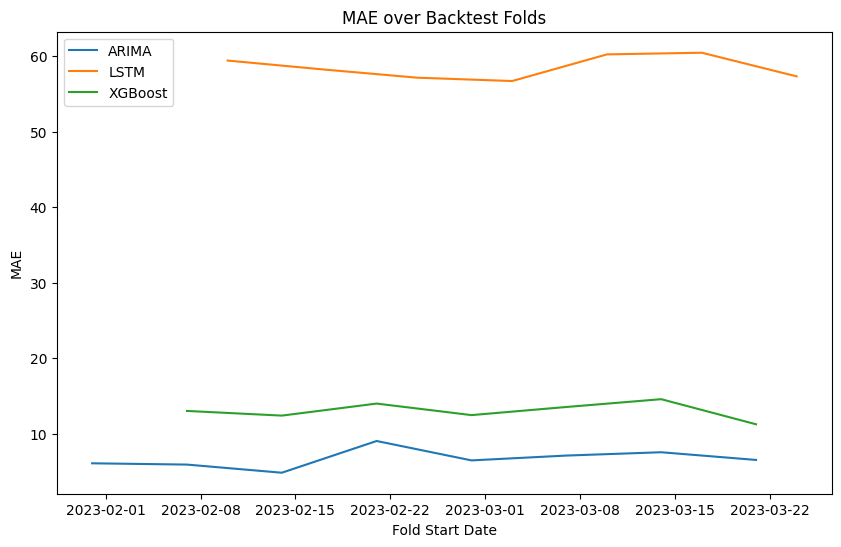

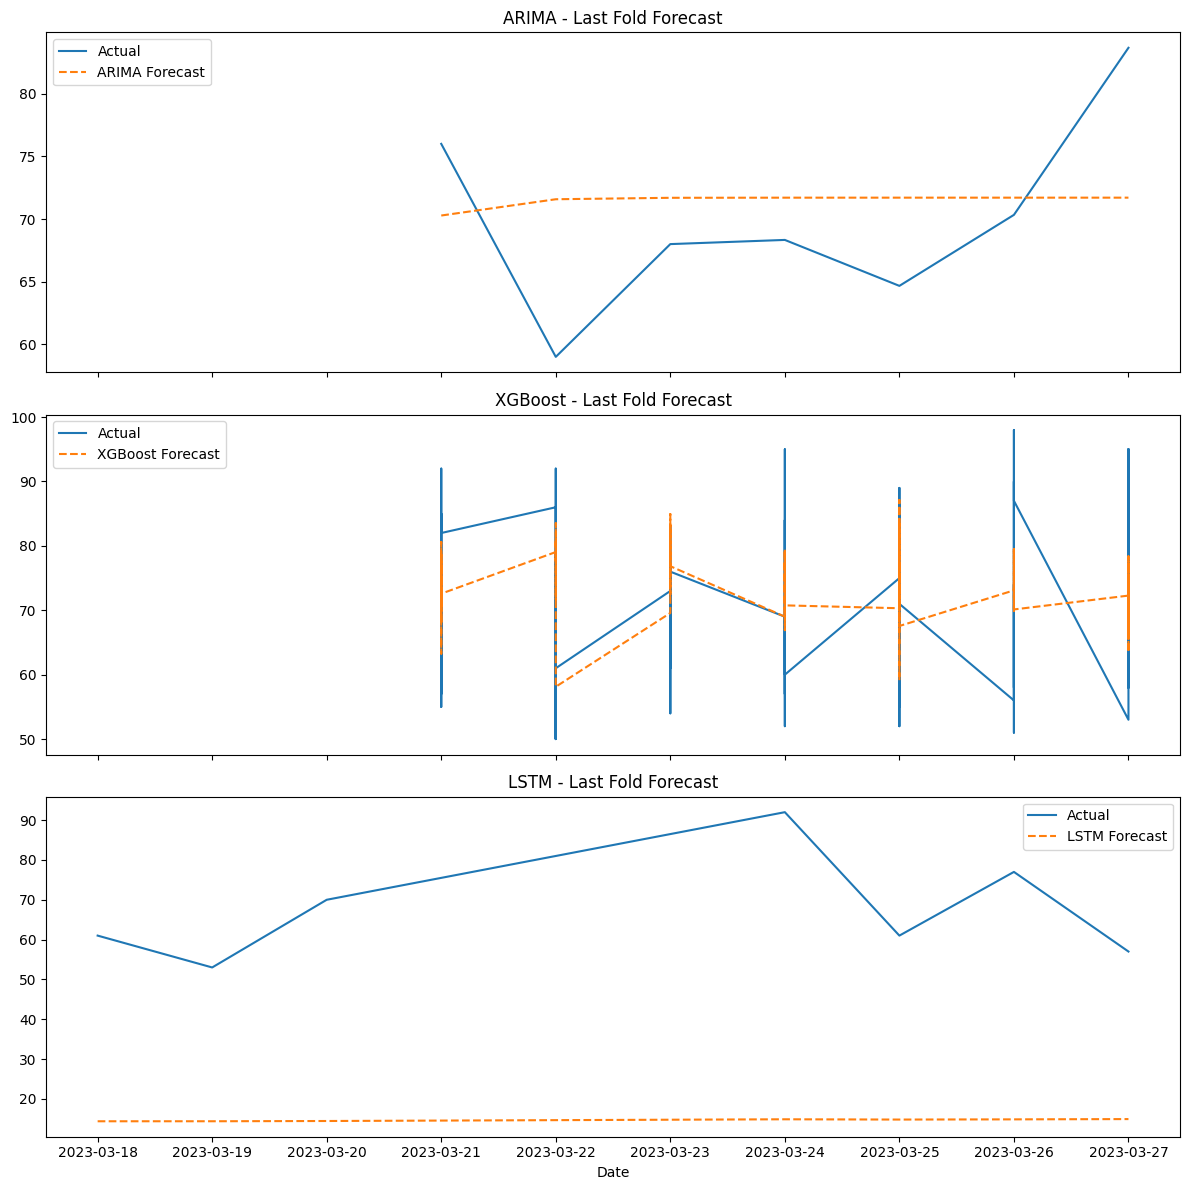

In [8]:
# Combine metrics for comparison
arima_metrics_df['Model'] = 'ARIMA'
xgb_metrics_df['Model'] = 'XGBoost'
lstm_metrics_df['Model'] = 'LSTM'
all_metrics = pd.concat([arima_metrics_df, xgb_metrics_df, lstm_metrics_df], ignore_index=True)
# Only display metrics if columns exist and DataFrame is not empty
metric_cols = [col for col in ['MAE','RMSE','MAPE','Bias'] if col in all_metrics.columns]
if not all_metrics.empty and metric_cols:
    display(all_metrics.groupby('Model')[metric_cols].mean())
else:
    print('No metrics to display. Check if any folds were generated and metric columns exist.')

# Plot MAE over folds if available
if 'MAE' in all_metrics.columns and not all_metrics.empty:
    plt.figure(figsize=(10,6))
    for model, df in all_metrics.groupby('Model'):
        plt.plot(df['start'], df['MAE'], label=model)
    plt.title('MAE over Backtest Folds')
    plt.xlabel('Fold Start Date')
    plt.ylabel('MAE')
    plt.legend()
    plt.show()
else:
    print('No MAE data to plot.')

# Plot example forecasts for last fold if available
import pandas as pd
fig, ax = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
for i, (name, df) in enumerate(zip(['ARIMA','XGBoost','LSTM'], [arima_forecast_df, xgb_forecast_df, lstm_forecast_df])):
    try:
        if not df.empty and 'date' in df.columns and 'actual' in df.columns and 'forecast' in df.columns:
            # Drop NaT and ensure datetime
            plot_df = df.dropna(subset=['date']).copy()
            plot_df['date'] = pd.to_datetime(plot_df['date'], errors='coerce')
            plot_df = plot_df.dropna(subset=['date'])
            if plot_df.empty:
                ax[i].set_title(f'{name} - No Data')
                continue
            # Get last fold by finding the last FORECAST_HORIZON dates
            plot_df = plot_df.sort_values('date')
            last_dates = plot_df['date'].unique()[-FORECAST_HORIZON:]
            last_fold = plot_df[plot_df['date'].isin(last_dates)]
            if last_fold.empty:
                ax[i].set_title(f'{name} - No Data')
                continue
            ax[i].plot(last_fold['date'], last_fold['actual'], label='Actual')
            ax[i].plot(last_fold['date'], last_fold['forecast'], label=f'{name} Forecast', linestyle='--')
            ax[i].set_title(f'{name} - Last Fold Forecast')
            ax[i].legend()
        else:
            ax[i].set_title(f'{name} - No Data')
    except Exception as e:
        ax[i].set_title(f'{name} - Error: {e}')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

## 5. Conclusion and Model Selection
Summarize findings, discuss model stability and accuracy, and recommend the best model for deployment based on backtesting results.

### Step 5: Final Model Selection
#### Criteria for Model Selection:

- **Accuracy:** Choose the model with the lowest average error metrics (MAE, RMSE, MAPE) across all folds.
- **Stability:** Prefer models with consistent performance (low variance in error metrics across folds).
- **Scalability:** Consider how well the model can handle larger datasets as your data grows.
- **Latency:** Evaluate inference speed for real-time or dashboard applications.

#### Outcome:

- For each region/service, select the model that best balances accuracy, stability, scalability, and latency.
- Optionally, select a single global model if performance is similar across regions/services.
- Document the selected model(s) and rationale for deployment.

---

In [13]:
import numpy as np
import os
import json

# Calculate mean and std for each model
summary = all_metrics.groupby('Model').agg(
    MAE_mean=('MAE', 'mean'),
    MAE_std=('MAE', 'std'),
    RMSE_mean=('RMSE', 'mean'),
    MAPE_mean=('MAPE', 'mean')
).reset_index()

# Rank by lowest MAE, then lowest RMSE, then lowest MAPE
summary['rank'] = summary[['MAE_mean', 'RMSE_mean', 'MAPE_mean']].rank(method='min').sum(axis=1)
best_model_row = summary.loc[summary['rank'].idxmin()]
best_model = best_model_row['Model']

print('Model selection summary:')
print(summary)
print(f'\nBest model based on MAE, RMSE, and MAPE: {best_model}')

# Add best model info to summary


# Ensure data folder exists
os.makedirs("../data", exist_ok=True)

# Save summary as JSON
json_path = "../data/model-metrices.json"
summary.to_json(json_path, orient="records", indent=4)

# Display JSON content below
with open(json_path, "r") as f:
    data = json.load(f)

print("\nSaved JSON:")
print(json.dumps(data, indent=4))


Model selection summary:
     Model   MAE_mean   MAE_std  RMSE_mean  MAPE_mean  rank
0    ARIMA   6.695431  1.247299   8.077762   9.026908   3.0
1     LSTM  58.486794  1.535793  60.153178  78.111664   9.0
2  XGBoost  13.036441  1.113970  15.571020  18.455493   6.0

Best model based on MAE, RMSE, and MAPE: ARIMA

Saved JSON:
[
    {
        "Model": "ARIMA",
        "MAE_mean": 6.6954308522,
        "MAE_std": 1.2472985195,
        "RMSE_mean": 8.0777615045,
        "MAPE_mean": 9.0269084989,
        "rank": 3.0
    },
    {
        "Model": "LSTM",
        "MAE_mean": 58.4867937127,
        "MAE_std": 1.5357926024,
        "RMSE_mean": 60.1531781956,
        "MAPE_mean": 78.1116644685,
        "rank": 9.0
    },
    {
        "Model": "XGBoost",
        "MAE_mean": 13.0364408169,
        "MAE_std": 1.1139703343,
        "RMSE_mean": 15.571019902,
        "MAPE_mean": 18.4554933541,
        "rank": 6.0
    }
]
